# **Phase1_EDA**

Loading dataset...

--- Basic Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7973 non-null   int64  
 1   V1      7973 non-null   float64
 2   V2      7973 non-null   float64
 3   V3      7973 non-null   float64
 4   V4      7973 non-null   float64
 5   V5      7973 non-null   float64
 6   V6      7973 non-null   float64
 7   V7      7973 non-null   float64
 8   V8      7973 non-null   float64
 9   V9      7973 non-null   float64
 10  V10     7973 non-null   float64
 11  V11     7973 non-null   float64
 12  V12     7973 non-null   float64
 13  V13     7973 non-null   float64
 14  V14     7973 non-null   float64
 15  V15     7972 non-null   float64
 16  V16     7972 non-null   float64
 17  V17     7972 non-null   float64
 18  V18     7972 non-null   float64
 19  V19     7972 non-null   float64
 20  V20     7972 non-null   flo

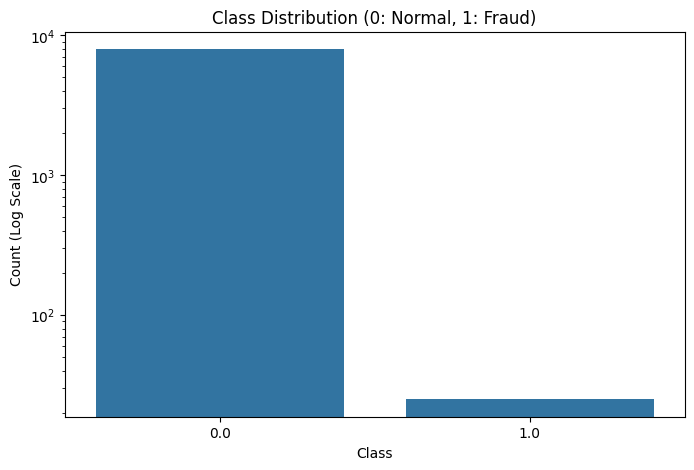

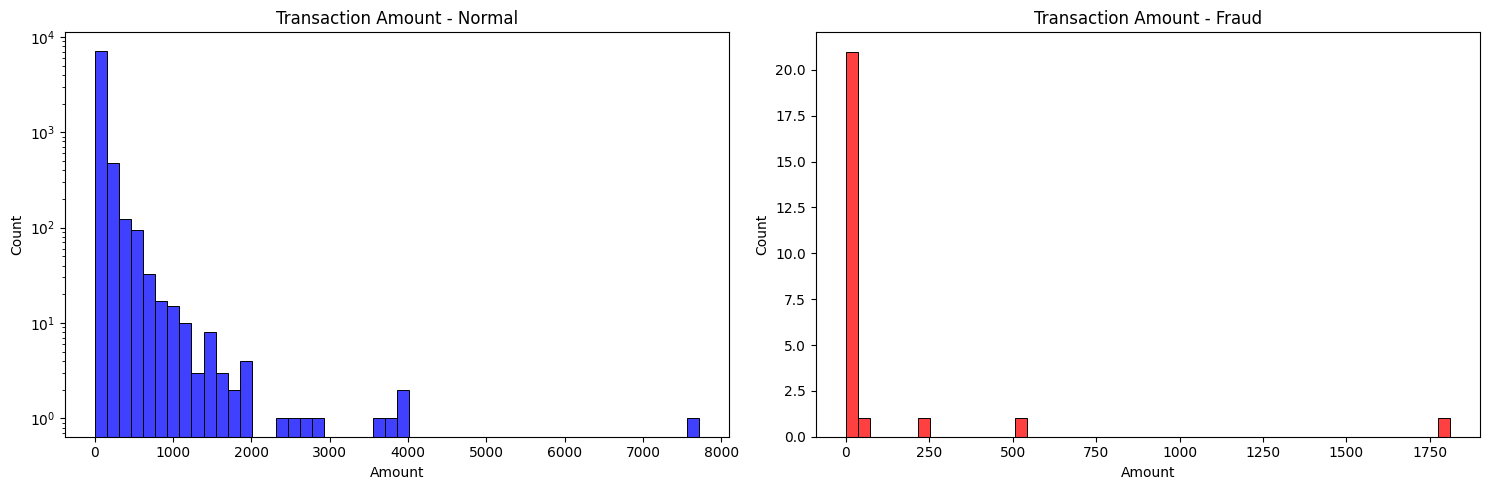

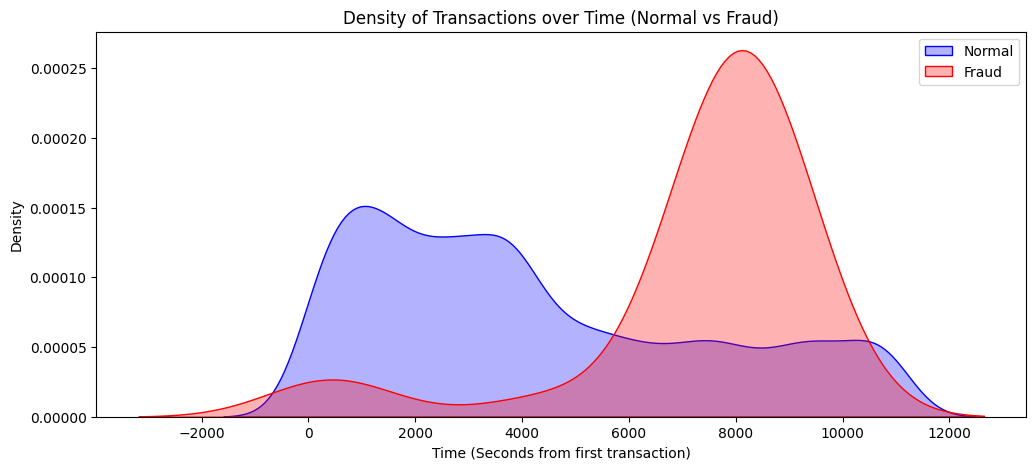

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
print("Loading dataset...")
df = pd.read_csv('/content/creditcard.csv')

# 2. Check basic info and missing values
print("\n--- Basic Dataset Info ---")
print(df.info())
print("\nTotal missing values:", df.isnull().sum().max())

# 3. Analyze Class Imbalance
class_counts = df['Class'].value_counts()
print("\n--- Class Distribution ---")
print(class_counts)

fraud_pct = (class_counts[1] / len(df)) * 100
print(f"\nFraud accounts for ONLY {fraud_pct:.3f}% of all transactions.")
print("Takeaway: A 'dumb' model that blindly guesses '0' (Normal) for every transaction will be 99.827% accurate.")
print("This is why standard 'Accuracy' is useless for fraud detection!")

# 4. Plot the Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # We use a log scale because the imbalance is so extreme
plt.ylabel('Count (Log Scale)')
plt.show()

# 5. Amount Distribution (Fraud vs Normal)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', ax=ax[0])
ax[0].set_title('Transaction Amount - Normal')
ax[0].set_yscale('log')

sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', ax=ax[1])
ax[1].set_title('Transaction Amount - Fraud')
plt.tight_layout()
plt.show()

# 6. Time Distribution (Fraud vs Normal)
plt.figure(figsize=(12, 5))
sns.kdeplot(df[df['Class'] == 0]['Time'], color='blue', label='Normal', fill=True, alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['Time'], color='red', label='Fraud', fill=True, alpha=0.3)
plt.title('Density of Transactions over Time (Normal vs Fraud)')
plt.xlabel('Time (Seconds from first transaction)')
plt.ylabel('Density')
plt.legend()
plt.show()


# **Phase2_Baseline Model**

Splitting data into train and test sets...
Scaling 'Time' and 'Amount' features...

Training Logistic Regression Baseline...

--- Logistic Regression Baseline Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      1.00      1.00         5

    accuracy                           1.00      1595
   macro avg       1.00      1.00      1.00      1595
weighted avg       1.00      1.00      1.00      1595

PR-AUC (Precision-Recall Area Under Curve): 1.0000


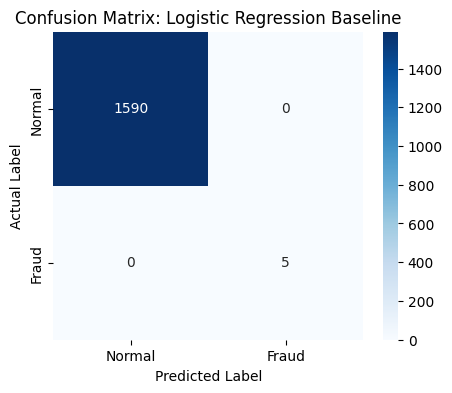


Training Random Forest Baseline (n_estimators=50, max_depth=10)...

--- Random Forest Baseline Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      0.80      0.89         5

    accuracy                           1.00      1595
   macro avg       1.00      0.90      0.94      1595
weighted avg       1.00      1.00      1.00      1595

PR-AUC (Precision-Recall Area Under Curve): 1.0000


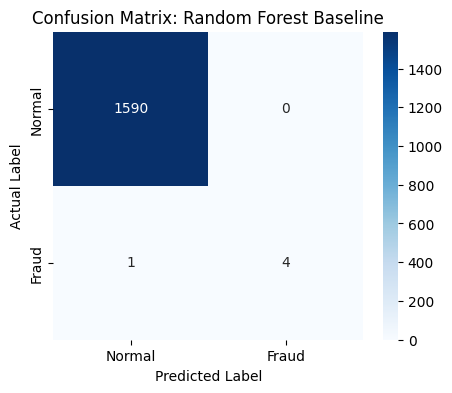

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# --- NEW: Drop any rows with missing values ---
df = df.dropna()

# 1. Train-Test Split
X = df.drop('Class', axis=1)
y = df['Class']

# stratify=y is CRITICAL. It ensures both train and test sets have exactly 0.17% fraud
print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale Features (Time and Amount)
print("Scaling 'Time' and 'Amount' features...")
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# Helper Function for Evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*40}")
    print(f"--- {model_name} Evaluation ---")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))

    # Calculate PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    print(f"PR-AUC (Precision-Recall Area Under Curve): {pr_auc:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 3. Train Logistic Regression
print("\nTraining Logistic Regression Baseline...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression Baseline")

# 4. Train Random Forest (Restricted size to avoid Colab RAM crash)
print("\nTraining Random Forest Baseline (n_estimators=50, max_depth=10)...")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest Baseline")


# **Phase3 Imbalance**

Applying SMOTE to the training data...
Original Training shape: (6377, 30)
Original Training Frauds: 20
SMOTE Training shape: (12714, 30)
SMOTE Training Frauds: 6357

Training Random Forest on SMOTE data...

Training Random Forest with Class Weights (No SMOTE)...

--- Evaluation: Random Forest (SMOTE) ---

--- Random Forest (SMOTE) Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      0.80      0.89         5

    accuracy                           1.00      1595
   macro avg       1.00      0.90      0.94      1595
weighted avg       1.00      1.00      1.00      1595

PR-AUC (Precision-Recall Area Under Curve): 1.0000


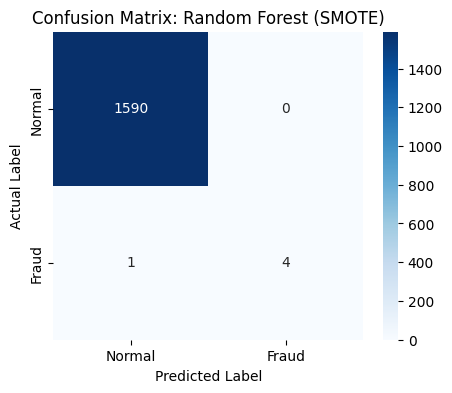


--- Evaluation: Random Forest (Class Weights) ---

--- Random Forest (Class Weights) Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      0.80      0.89         5

    accuracy                           1.00      1595
   macro avg       1.00      0.90      0.94      1595
weighted avg       1.00      1.00      1.00      1595

PR-AUC (Precision-Recall Area Under Curve): 1.0000


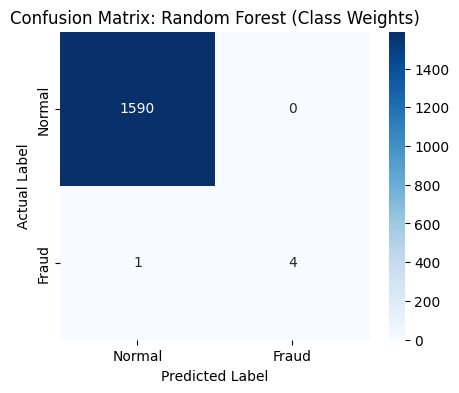

In [4]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE ONLY to the Training Set!
# We NEVER apply SMOTE to the test set, because we need to test on real-world distributions.
print("Applying SMOTE to the training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training shape: {X_train_scaled.shape}")
print(f"Original Training Frauds: {sum(y_train == 1)}")
print(f"SMOTE Training shape: {X_train_smote.shape}")
print(f"SMOTE Training Frauds: {sum(y_train_smote == 1)}")

# 2. Train Random Forest on SMOTE data
print("\nTraining Random Forest on SMOTE data...")
rf_smote = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

# 3. Train Random Forest using Class Weights (Algorithm-level approach)
print("\nTraining Random Forest with Class Weights (No SMOTE)...")
rf_weighted = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_weighted.fit(X_train_scaled, y_train)

# Evaluate both approaches
# (Assumes evaluate_model function from Phase 2 is still in memory)
print("\n--- Evaluation: Random Forest (SMOTE) ---")
evaluate_model(rf_smote, X_test_scaled, y_test, "Random Forest (SMOTE)")

print("\n--- Evaluation: Random Forest (Class Weights) ---")
evaluate_model(rf_weighted, X_test_scaled, y_test, "Random Forest (Class Weights)")


# **Phase 4: Gradient Boosting Ensemble (LightGBM).**

In [5]:
!pip install optuna lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.6 MB/s eta 0:00:00


[I 2026-06-08 18:07:06,127] A new study created in memory with name: no-name-0887ff53-5b9c-4d96-b33e-d207f101c826


Calculated scale_pos_weight: 317.85

--- Running Optuna Hyperparameter Tuning ---


[I 2026-06-08 18:07:07,337] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 68, 'learning_rate': 0.011107408156038378, 'num_leaves': 36, 'max_depth': 7}. Best is trial 0 with value: 1.0.
[I 2026-06-08 18:07:07,841] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 126, 'learning_rate': 0.017758146481853882, 'num_leaves': 41, 'max_depth': 4}. Best is trial 0 with value: 1.0.
[I 2026-06-08 18:07:08,367] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 96, 'learning_rate': 0.040620637054869006, 'num_leaves': 42, 'max_depth': 6}. Best is trial 0 with value: 1.0.
[I 2026-06-08 18:07:08,598] Trial 3 finished with value: 0.001567398119122257 and parameters: {'n_estimators': 51, 'learning_rate': 0.058825077990955946, 'num_leaves': 24, 'max_depth': 3}. Best is trial 0 with value: 1.0.
[I 2026-06-08 18:07:08,879] Trial 4 finished with value: 1.0 and parameters: {'n_estimators': 150, 'learning_rate': 0.015016578655215981, 'num_leaves': 70, 'max_d


Best Parameters found by Optuna:
{'n_estimators': 68, 'learning_rate': 0.011107408156038378, 'num_leaves': 36, 'max_depth': 7}

--- Training Final LightGBM Model ---

--- LightGBM (Tuned) Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      1.00      1.00         5

    accuracy                           1.00      1595
   macro avg       1.00      1.00      1.00      1595
weighted avg       1.00      1.00      1.00      1595

PR-AUC (Precision-Recall Area Under Curve): 1.0000


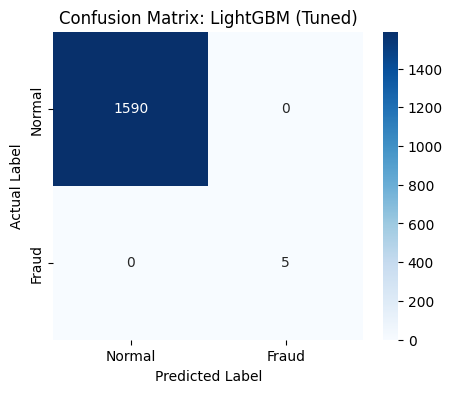

In [6]:
import lightgbm as lgb
import optuna

# 1. Calculate the optimal 'scale_pos_weight'
# This tells LightGBM exactly how much more important a Fraud case is compared to a Normal case
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# 2. Define the Optuna Objective Function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    # We train on the standard scaled data, NOT the SMOTE data.
    # LightGBM handles the imbalance natively using 'scale_pos_weight'
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    return auc(recall, precision) # We tell Optuna to maximize the PR-AUC score!

# 3. Run Optuna Study (We'll do 10 trials to keep it fast)
print("\n--- Running Optuna Hyperparameter Tuning ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("\nBest Parameters found by Optuna:")
print(study.best_params)

# 4. Train the Final Tuned Model
print("\n--- Training Final LightGBM Model ---")
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

final_lgb = lgb.LGBMClassifier(**best_params)
final_lgb.fit(X_train_scaled, y_train)

# Evaluate!
# (Assumes evaluate_model function from earlier is still in memory)
evaluate_model(final_lgb, X_test_scaled, y_test, "LightGBM (Tuned)")


#**Phase 5: SHAP Explainability**

In [7]:
!pip install shap



--- Generating SHAP Explanations ---
Calculating SHAP values (this might take a few seconds)...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Plotting Global Feature Importance (Summary Plot)...


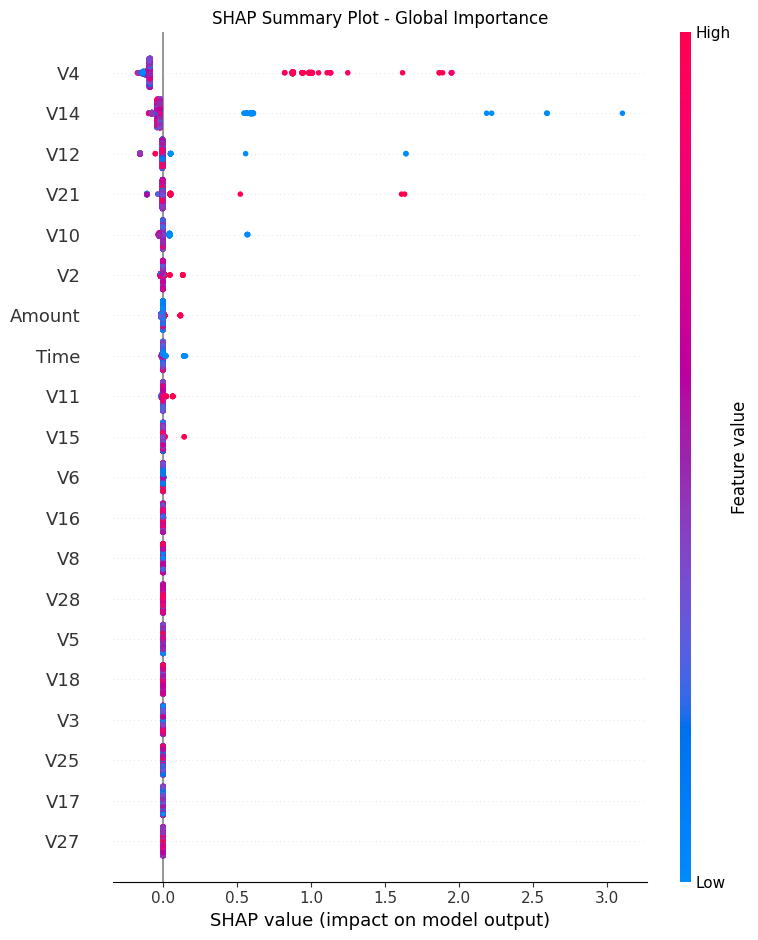


Plotting Local Explanation (Waterfall Plot) for a specific Fraud Transaction...


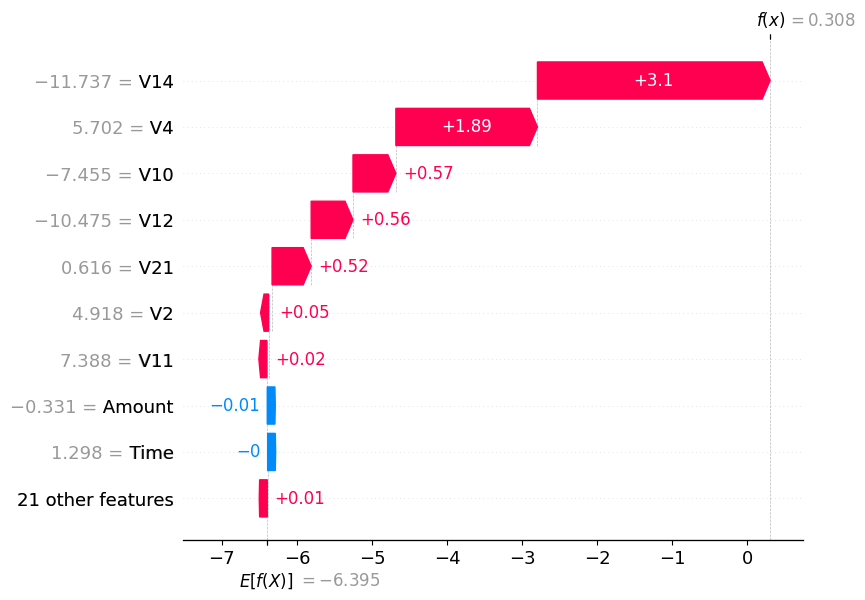

In [8]:
import shap

print("\n--- Generating SHAP Explanations ---")
# 1. Initialize TreeExplainer (optimized for tree models like LightGBM)
explainer = shap.TreeExplainer(final_lgb)

# We sample up to 1000 rows. Calculating SHAP on 50,000+ rows is too slow/RAM-heavy.
sample_size = min(1000, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=42)

print("Calculating SHAP values (this might take a few seconds)...")
shap_values = explainer.shap_values(X_test_sample)

# --- Global Explainability: What features does the model care about overall? ---
print("\nPlotting Global Feature Importance (Summary Plot)...")
# LightGBM outputs a list of arrays [Class 0, Class 1]. We want to explain Class 1 (Fraud)
shap_vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - Global Importance")
shap.summary_plot(shap_vals_to_plot, X_test_sample, show=True)

# --- Local Explainability: Why was THIS specific transaction flagged? ---
fraud_indices = y_test[y_test == 1].index
if len(fraud_indices) > 0:
    # Pick the first fraud transaction we can find
    fraud_idx = fraud_indices[0]
    iloc_idx = X_test_scaled.index.get_loc(fraud_idx)

    print("\nPlotting Local Explanation (Waterfall Plot) for a specific Fraud Transaction...")
    # Generate the explanation object for just this one row
    explanation = explainer(X_test_scaled.iloc[[iloc_idx]])

    plt.figure()
    if len(explanation.shape) == 3:
        shap.plots.waterfall(explanation[0, :, 1])
    else:
        shap.plots.waterfall(explanation[0])
else:
    print("No fraud cases found in the test set to explain.")


# **Phase 6: Production API (Deploying the Model)**

In [9]:
import joblib
from google.colab import files

print("Saving the best LightGBM model...")
# 'final_lgb' is the tuned model we trained in Phase 4
joblib.dump(final_lgb, 'fraud_model.joblib')

print("Downloading model to your computer...")
files.download('fraud_model.joblib')


Saving the best LightGBM model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>